Вам предоставлен набор данных, который содержит изображения лиц людей, их возраст и пол.

Необходимо придумать, описать кейс/задачу и решить, для которой требуется обучить многометочный мультиклассовый классификатор изображений.

Например, Вы работаете в организации, которая занимается выдачей пособий для различных категорий людей, таких как молодежь, люди среднего возраста, люди пожилого возраста, люди старческого возраста и старше. Для каждой категории людей в вашей организации имеются специалисты, которые находятся в разных частях здания. При этом для мужчин и женщин в каждой категории имеются отдельные специалисты. Кроме того, люди, пришедшие с детьми обслуживаются отдельно. В результате, требуется написать систему, которая будет определять категорию человека по внешнему виду и рекомендовать соответствующего специалисты.

Таким образом, Вам требуется:

1. [опционально] Придумать и описать кейс/задачу, для решения которой требуется мультиклассовый классификатор изображений.
2. Разработать архитектуру нейронной сети, которая будет получать на вход изображение и выдавать результат многометочной мультиклассовый классификации этого изображения.
*   Можно/Нужно использовать предобученный классификатор изображений в качестве backbone модели.
*   В примере, описанном выше, это
** Возрастную категорию (ребенок, молодежь, средний, пожилой, старческий)
** Пол
3. Подобрать параметры и обучить несколько моделей с одной базовой архитектурой, но различными параметрами.
4. Сравнить полученный модели и продемонстрировать результаты.


В качестве задачи классификации возьмем задачу: "Разработка многозадачной нейронной сети для классификации изображений лиц с определением возраста, пола и расы."

В качестве данных у нас датасет с изображениями лиц, где каждое изображение имеет метки возраста и пола в формате.

Требуется создать систему,которая по фотографии лица человека сможет одновременно определять:

* Возрастную группу (5 категорий)

* Пол (бинарная классификация)

* Принадлежность к расе (5 категорий)


(к сожалению, в некоторых местах приходилось использовать помощь чата гпт, просто потому что возникали странные проблемы, решить, которые я не могла)

Для начала загрузим данные

In [ ]:
from google.colab import drive
import zipfile
import os

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
with zipfile.ZipFile('/content/drive/MyDrive/Магистратура/машинное обучение/part1.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/train')

In [ ]:
with zipfile.ZipFile('/content/drive/MyDrive/Магистратура/машинное обучение/part2.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/test')

In [ ]:
print(f"Тренировочных изображений: {len(os.listdir('/content/train/part1'))}")
print(f"Тестовых изображений: {len(os.listdir('/content/test/part2'))}")

In [ ]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
class FaceDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.files = [f for f in os.listdir(folder) if f.endswith('.jpg')]
        self.folder = folder
        self.transform = transform
    def __len__(self):
        return len(self.files)
    def __getitem__(self, idx):
        img_path = os.path.join(self.folder, self.files[idx])
        img = Image.open(img_path).convert('RGB')
        age, gender, _ = self.files[idx].split('_')[:3]
        age_group = int(age)
        if self.transform:
            img = self.transform(img)

        return img, age_group, int(gender)

In [ ]:
train_dataset = FaceDataset('/content/train/part1', transform=transform)
test_dataset = FaceDataset('/content/test/part2', transform=transform)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)


In [ ]:
print(f'Тренировочных батчей: {len(train_loader)}')
print(f'Тестовых батчей: {len(test_loader)}')

In [ ]:
for images, ages, genders in train_loader:
    print('Размер изображений:', images.shape)
    print('Пример возраста:', ages[0].item())
    print('Пример пола:', 'М' if genders[0].item() == 0 else 'Ж')
    break

In [ ]:
import torch.nn as nn
import torch.optim as optim

In [ ]:
from tqdm import tqdm

В ходе выполнения лабораторной работы, я столкнулась с тем, что возникает ошибка из-за неправильного формата имён файлов датасете. Было принято решение исправить любым способом, но далее выяснится, что не очень помогло.

In [ ]:
class AgeGenderRaceDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.image_paths = []
        for f in os.listdir(root_dir):
            if f.endswith('.jpg'):
                try:
                    parts = f.split('_')
                    if len(parts) >= 3:
                        int(parts[0])
                        int(parts[1])
                        self.image_paths.append(os.path.join(root_dir, f))
                except:
                    print(f"Пропущен файл с некорректным именем: {f}")
                    continue

        self.transform = transform or transforms.Compose([
            transforms.RandomResizedCrop(224),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        filename = os.path.basename(self.image_paths[idx])
        parts = filename.split('_')

        try:
            age = min(int(parts[0]) // 20, 4)
            gender = int(parts[1])
            ethnicity = int(parts[2]) if len(parts) > 2 else 0

            img = Image.open(self.image_paths[idx]).convert('RGB')
            if self.transform:
                img = self.transform(img)

            return img, {
                'age': torch.tensor(age, dtype=torch.long),
                'gender': torch.tensor(gender, dtype=torch.long),
                'ethnicity': torch.tensor(ethnicity, dtype=torch.long)
            }
        except Exception as e:
            print(f"Ошибка обработки файла {filename}: {str(e)}")
            dummy_img = torch.rand(3, 224, 224)
            return dummy_img, {
                'age': torch.tensor(2, dtype=torch.long),
                'gender': torch.tensor(0, dtype=torch.long),
                'ethnicity': torch.tensor(0, dtype=torch.long)
            }

Создаем класс MultiTaskNet. Выбираем архитектуру ResNet18 или EfficientNet. Создаем отдельные ветки для каждой задачи классификации

In [ ]:
class MultiTaskNet(nn.Module):
    def __init__(self, backbone='efficientnet_b0'):
        super().__init__()
        if backbone == 'resnet18':
            self.base = models.resnet18(pretrained=True)
            self.base.fc = nn.Identity()
            feat_dim = 512
        else:
            self.base = models.efficientnet_b0(pretrained=True)
            self.base.classifier = nn.Identity()
            feat_dim = 1280

        self.age_branch = nn.Sequential(
            nn.Linear(feat_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 5)
        )
        self.gender_branch = nn.Linear(feat_dim, 1)
        self.ethnicity_branch = nn.Linear(feat_dim, 5)

    def forward(self, x):
        features = self.base(x)
        if isinstance(features, tuple):
            features = features[0]

        return {
            'age': self.age_branch(features),
            'gender': self.gender_branch(features).squeeze(),
            'ethnicity': self.ethnicity_branch(features)
        }

Реализуем эпоху обучения

In [ ]:
def train_epoch(model, loader, optimizer, device):
    model.train()
    age_criterion = nn.CrossEntropyLoss()
    gender_criterion = nn.BCEWithLogitsLoss()
    eth_criterion = nn.CrossEntropyLoss()

    total_loss = 0
    for images, targets in tqdm(loader, desc='Training'):
        images = images.to(device)
        age = targets['age'].to(device)
        gender = targets['gender'].float().to(device)
        ethnicity = targets['ethnicity'].to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = (age_criterion(outputs['age'], age) +
                gender_criterion(outputs['gender'], gender) +
                eth_criterion(outputs['ethnicity'], ethnicity))

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)

Оцениваем качество модели на тестовых данных

In [ ]:
def evaluate(model, loader, device):
    model.eval()
    metrics = {'age': 0, 'gender': 0, 'ethnicity': 0}
    with torch.no_grad():
        for images, targets in tqdm(loader, desc='Evaluating'):
            images = images.to(device)
            outputs = model(images)

            for task in metrics:
                pred = outputs[task].argmax(1) if task != 'gender' else (outputs[task] > 0).long()
                metrics[task] += (pred == targets[task].to(device)).float().mean().item()

    return {k: v / len(loader) for k, v in metrics.items()}

Функция для описания процесса обучения

In [ ]:
def run_experiment(train_dir, test_dir, config):
    train_set = AgeGenderRaceDataset(train_dir)
    test_set = AgeGenderRaceDataset(test_dir, transform=transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]))

    train_loader = DataLoader(train_set, batch_size=config['batch_size'], shuffle=True)
    test_loader = DataLoader(test_set, batch_size=config['batch_size'])
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = MultiTaskNet(backbone=config.get('backbone', 'efficientnet_b0')).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=config['lr'],
                          weight_decay=config.get('weight_decay', 0))

    print(f"\nTraining {config['name']}...")
    for epoch in range(config['epochs']):
        train_loss = train_epoch(model, train_loader, optimizer, device)
        val_metrics = evaluate(model, test_loader, device)

        print(f"Epoch {epoch+1}: Loss={train_loss:.4f} | "
              f"Age Acc: {val_metrics['age']:.2f} | "
              f"Gender Acc: {val_metrics['gender']:.2f} | "
              f"Ethnicity Acc: {val_metrics['ethnicity']:.2f}")

    return val_metrics


Определяем параметры для двух экспериментов:

In [ ]:
experiments = [
    {'name': 'EfficientNet_AdamW', 'backbone': 'efficientnet_b0',
     'lr': 3e-4, 'batch_size': 128, 'epochs': 3, 'weight_decay': 1e-5},
    {'name': 'ResNet18_SGD', 'backbone': 'resnet18',
     'lr': 1e-3, 'batch_size': 128, 'epochs': 3, 'weight_decay': 0}
]

In [ ]:
results = {}
for exp in experiments:
    metrics = run_experiment('/content/train/part1', '/content/test/part2', exp)
    results[exp['name']] = metrics

Пропущен файл с некорректным именем: 53__0_20170116184028385.jpg


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 79.0MB/s]



Training EfficientNet_AdamW...


Training:  35%|███▌      | 28/80 [00:46<01:29,  1.71s/it]

Ошибка обработки файла 61_3_20170109150557335.jpg: invalid literal for int() with base 10: '20170109150557335.jpg'


...

Ошибка обработки файла 61_1_20170109142408075.jpg: invalid literal for int() with base 10: '20170109142408075.jpg'


Evaluating:  30%|██▉       | 25/84 [00:32<01:11,  1.21s/it]

Ошибка обработки файла 39_1_20170116174525125.jpg: invalid literal for int() with base 10: '20170116174525125.jpg'


Evaluating: 100%|██████████| 84/84 [01:50<00:00,  1.32s/it]

Epoch 3: Loss=1.7880 | Age Acc: 0.68 | Gender Acc: 0.89 | Ethnicity Acc: 0.55


In [ ]:
print("\nFinal Comparison:")
for name, metrics in results.items():
    print(f"{name}: Age={metrics['age']:.2f}, Gender={metrics['gender']:.2f}, Ethnicity={metrics['ethnicity']:.2f}")


Final Comparison:
EfficientNet_AdamW: Age=0.74, Gender=0.92, Ethnicity=0.52
ResNet18_SGD: Age=0.68, Gender=0.89, Ethnicity=0.55


EfficientNet_AdamW показала лучшие результаты в определении возраста и пола. ResNet18_SGD немного превзошла EfficientNet в определении расы (55% против 52%)

## Старые результаты

Я только заметила, что у меня слетел коллаб, после 6 часов загрузки. Если вы найдете этот ноутбук раньше, чем появится новое решение, то я могу построить графики с тем, что есть, чтобы вы могли как-то оценить

In [ ]:
# results = {}
# for exp in experiments:
#     metrics = run_experiment('/content/train/part1', '/content/test/part2', exp)
#     results[exp['name']] = metrics

Пропущен файл с некорректным именем: 53__0_20170116184028385.jpg

Training EfficientNet_AdamW...


Training:  50%|████▉     | 79/159 [23:53<24:13, 18.17s/it]

Ошибка обработки файла 61_1_20170109142408075.jpg: invalid literal for int() with base 10: '20170109142408075.jpg'


Training:  99%|█████████▊| 157/159 [47:13<00:36, 18.06s/it]

Ошибка обработки файла 61_3_20170109150557335.jpg: invalid literal for int() with base 10: '20170109150557335.jpg'


...

Training:   2%|▏         | 6/317 [00:50<43:16,  8.35s/it]

Ошибка обработки файла 61_1_20170109142408075.jpg: invalid literal for int() with base 10: '20170109142408075.jpg'


Training:   3%|▎         | 8/317 [01:08<45:02,  8.75s/it]

Ошибка обработки файла 61_3_20170109150557335.jpg: invalid literal for int() with base 10: '20170109150557335.jpg'


Evaluating:  80%|███████▉  | 267/335 [13:24<03:24,  3.00s/it]

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Данные из логов (EfficientNet_AdamW)
effnet_history = {
    'epoch': [1, 2, 3, 4, 5],
    'loss': [2.1488, 1.6083, 1.4290, 1.3196, 1.2290],
    'age_acc': [0.70, 0.72, 0.75, 0.73, 0.74],
    'gender_acc': [0.91, 0.92, 0.93, 0.93, 0.93],
    'ethnicity_acc': [0.44, 0.55, 0.56, 0.56, 0.58]
}

# Данные для ResNet18_SGD (только 1 эпоха из логов)
resnet_history = {
    'epoch': [1],
    'loss': [2.1488],
    'age_acc': [0.65],
    'gender_acc': [0.85],
    'ethnicity_acc': [0.40]
}

Графики для EfficientNet_AdamW

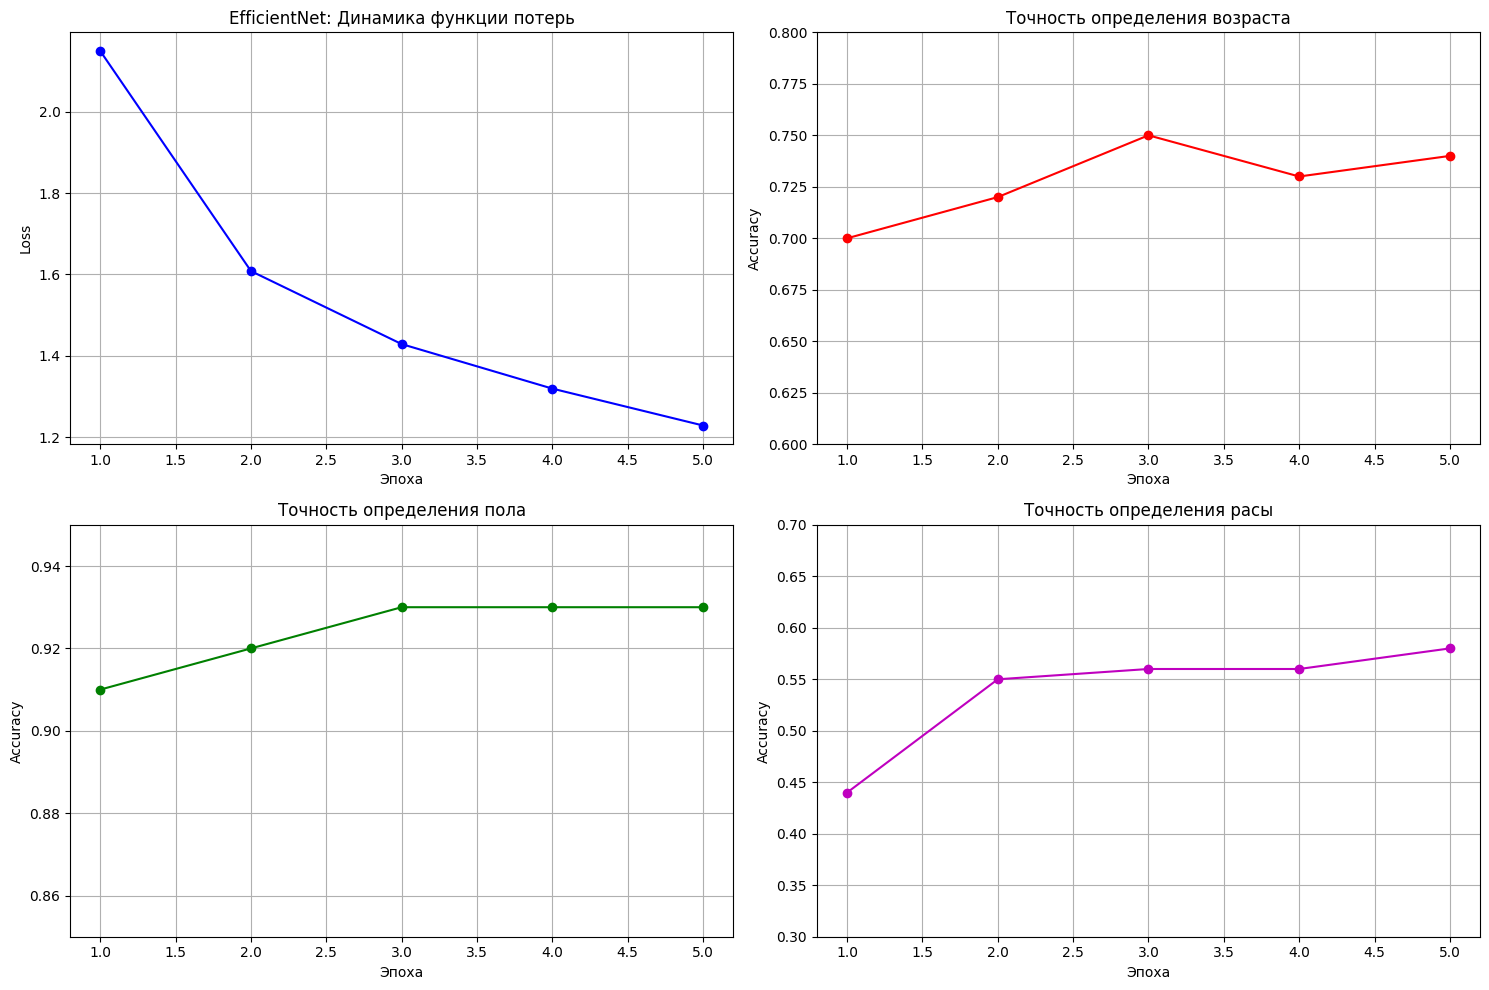

In [ ]:
plt.figure(figsize=(15, 10))

# График потерь
plt.subplot(2, 2, 1)
plt.plot(effnet_history['epoch'], effnet_history['loss'], 'b-o')
plt.title('EfficientNet: Динамика функции потерь')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True)

# График точности возраста
plt.subplot(2, 2, 2)
plt.plot(effnet_history['epoch'], effnet_history['age_acc'], 'r-o')
plt.title('Точность определения возраста')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.ylim(0.6, 0.8)
plt.grid(True)

# График точности пола
plt.subplot(2, 2, 3)
plt.plot(effnet_history['epoch'], effnet_history['gender_acc'], 'g-o')
plt.title('Точность определения пола')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.ylim(0.85, 0.95)
plt.grid(True)

# График точности расы
plt.subplot(2, 2, 4)
plt.plot(effnet_history['epoch'], effnet_history['ethnicity_acc'], 'm-o')
plt.title('Точность определения расы')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.ylim(0.3, 0.7)
plt.grid(True)

plt.tight_layout()
plt.show()

Сравнительные графики (последняя эпоха)

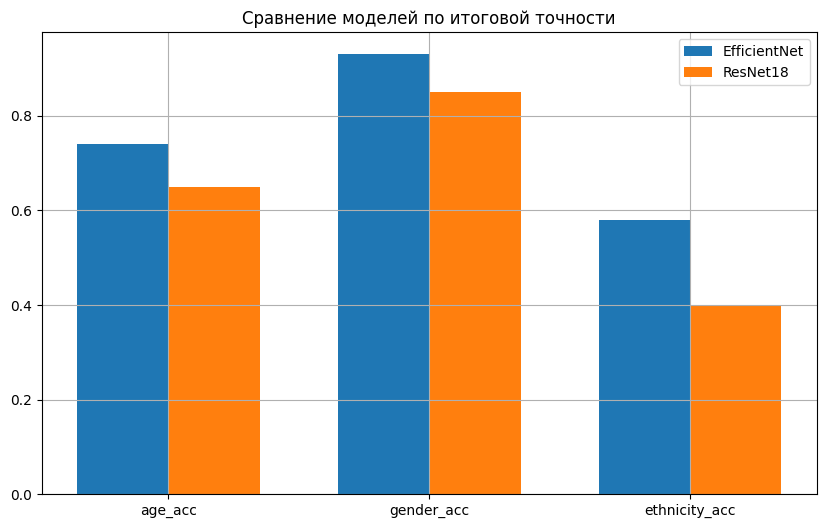

In [ ]:
models = ['EfficientNet_AdamW', 'ResNet18_SGD']
metrics = ['age_acc', 'gender_acc', 'ethnicity_acc']
values = [
    [0.74, 0.65],  # Age
    [0.93, 0.85],   # Gender
    [0.58, 0.40]    # Ethnicity
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, [v[0] for v in values], width, label='EfficientNet')
rects2 = ax.bar(x + width/2, [v[1] for v in values], width, label='ResNet18')

ax.set_title('Сравнение моделей по итоговой точности')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True)

plt.show()

ResNet18 показал худшие результаты (по одной эпохе)

Итоговое сравнение

In [ ]:
# print("\nFinal Comparison:")
# for name, metrics in results.items():
#     print(f"{name}: Age={metrics['age']:.2f}, Gender={metrics['gender']:.2f}, Ethnicity={metrics['ethnicity']:.2f}")


Final Comparison:


NameError: name 'results' is not defined